4.1. Rectified Linear Unit nonlinearity

To repoduce :

Figure 1. A four-layer convolutional neural network with ReLUs (solid line) reaches a 25% training error
rate on CIFAR-10 six times faster than an equivalent network with tanh neurons (dashed line).


The learning rates for each network were chosen independently to make training as fast as possible.
No regularization of any kind was employed.


The magnitude of the effect demonstrated here varies with network architecture, but networks with ReLUs
consistently learn several times faster than equivalents with saturating neurons.

In [1]:
import os
#os.environ["KERAS_BACKEND"] = "torch"

In [2]:
import keras
import pandas as pd
import matplotlib.pyplot as plt
from keras.src.legacy.preprocessing.image import ImageDataGenerator

#### Load Dataset

In [3]:

# (x_train, y_train), (x_test, y_test) = keras.datasets.cifar10.load_data() # The source url through put is slow
dir = "cifar-10"
train_data_path = os.path.join(dir, "train")
train_csv_path = os.path.join(dir, "trainLabels.csv")
train_data_path, train_csv_path

('cifar-10\\train', 'cifar-10\\trainLabels.csv')

In [4]:
df = pd.read_csv(train_csv_path)
df['id'] = df['id'].astype(str) + '.png'
datagen = ImageDataGenerator(rescale=1./255) # Standardizes pixel values between 0 and 1

# 5. Load the dataset using flow_from_dataframe
train_data = datagen.flow_from_dataframe(
    dataframe=df,
    directory=train_data_path,
    x_col="id",
    y_col="label",
    target_size=(32, 32),
    batch_size=32,
    class_mode="categorical"
)


Found 50000 validated image filenames belonging to 10 classes.


In [5]:
images, labels = next(train_data)

print("Images batch shape:", images.shape)
print("Labels batch shape:", labels.shape)
print("Class indices mapping:", train_data.class_indices)

Images batch shape: (32, 32, 32, 3)
Labels batch shape: (32, 10)
Class indices mapping: {'airplane': 0, 'automobile': 1, 'bird': 2, 'cat': 3, 'deer': 4, 'dog': 5, 'frog': 6, 'horse': 7, 'ship': 8, 'truck': 9}


[0. 0. 1. 0. 0. 0. 0. 0. 0. 0.]


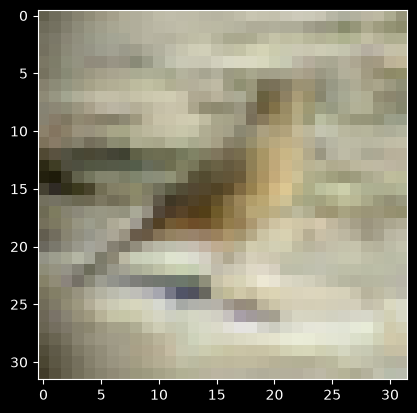

In [6]:
i = 1
print(labels[i])
plt.imshow(images[i])


#### Callback for 75% acc

In [7]:
class StopAtAccuracyCallback(keras.callbacks.Callback):
    def on_epoch_end(self, epoch, logs=None):
        accuracy = logs.get('accuracy')
        if accuracy is not None and accuracy >= 0.75:
            print(f"\nReached {accuracy*100:.2f}% accuracy at epoch {epoch+1}, stopping training!")
            self.model.stop_training = True

accuracy_callback = StopAtAccuracyCallback()

#### Model with Tanh

In [8]:
model_tanh = keras.Sequential(
    [
        keras.layers.Input(shape=(32, 32, 3)),
        keras.layers.Conv2D(32, (3, 3), activation='tanh'),
        keras.layers.Conv2D(64, (3, 3), activation='tanh'),
        keras.layers.Conv2D(128, (3, 3), activation='tanh'),
        keras.layers.Conv2D(256, (3, 3), activation='tanh'),
        keras.layers.Flatten(),
        keras.layers.Dense(10, "softmax")
    ]
)

In [ ]:
model_tanh.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

history_tanh = model_tanh.fit(train_data, epochs=50, callbacks=[accuracy_callback])

Epoch 1/50
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 233s 147ms/step - accuracy: 0.3314 - loss: 1.9436
Epoch 2/50
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 236s 151ms/step - accuracy: 0.3566 - loss: 1.8577
Epoch 3/50
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 240s 153ms/step - accuracy: 0.3685 - loss: 1.8282
Epoch 4/50
 232/1563 ━━━━━━━━━━━━━━━━━━━━ 3:36 162ms/step - accuracy: 0.3840 - loss: 1.7932

#### Model with ReLU

In [ ]:
model_relu = keras.Sequential(
    [
        keras.layers.Input(shape=(32, 32, 3)),
        keras.layers.Conv2D(32, (3, 3), activation='relu'),
        keras.layers.Conv2D(64, (3, 3), activation='relu'),
        keras.layers.Conv2D(128, (3, 3), activation='relu'),
        keras.layers.Conv2D(256, (3, 3), activation='relu'),
        keras.layers.Flatten(),
        keras.layers.Dense(10, "softmax")
    ]
)

In [ ]:
model_relu.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

history_relu = model_relu.fit(train_data, epochs=50, callbacks=[accuracy_callback])

#### Comparisions

In [ ]:
epoch_tanh = list(range(1, len(history_tanh.history["accuracy"])))
epoch_relu = list(range(1, len(history_relu.history["accuracy"])))
plt.plot(epoch_tanh, history_tanh.history["accuracy"], '-', label="tanh")
plt.plot(epoch_relu, history_relu.history["accuracy"], '--', label="relu")
plt.legend()
plt.xlabel("Train Accuracy")
plt.ylabel("Epochs")
plt.plot()


In [ ]:
epoch_tanh = list(range(1, len(history_tanh.history["accuracy"])))
epoch_relu = list(range(1, len(history_relu.history["accuracy"])))
plt.plot(epoch_tanh, 1-history_tanh.history["accuracy"], '-', label="tanh")
plt.plot(epoch_relu, 1-history_relu.history["accuracy"], '--', label="relu")
plt.legend()
plt.xlabel("Train error")
plt.ylabel("Epochs")
plt.plot()
